<a href="https://colab.research.google.com/github/Dwayne-tech/DML/blob/main/Machine_learning_algorithms_checkpoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [ ]:
data = pd.read_csv("/content/Microsoft_malware_dataset_min.csv")

In [ ]:
#Data Exploration
data.head()
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   HasDetections               100000 non-null  int64  
 1   Wdft_IsGamer                96585 non-null   float64
 2   Census_IsVirtualDevice      99815 non-null   float64
 3   Census_OSEdition            100000 non-null  object 
 4   Census_HasOpticalDiskDrive  100000 non-null  int64  
 5   Firewall                    98924 non-null   float64
 6   SMode                       94068 non-null   float64
 7   IsProtected                 99609 non-null   float64
 8   OsPlatformSubRelease        100000 non-null  object 
 9   CountryIdentifier           100000 non-null  int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 7.6+ MB


,HasDetections,Wdft_IsGamer,Census_IsVirtualDevice,Census_HasOpticalDiskDrive,Firewall,SMode,IsProtected,CountryIdentifier
count,100000.000000,96585.000000,99815.000000,100000.000000,98924.000000,94068.000000,99609.000000,100000.000000
mean,0.499280,0.281607,0.006642,0.075850,0.977326,0.000351,0.944864,108.188050
std,0.500002,0.449785,0.081230,0.264759,0.148863,0.018727,0.228246,62.989406
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,51.000000
50%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,97.000000
75%,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,162.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,222.000000


In [ ]:
# Check for missing values
print(data.isnull().sum())

# Handle missing values (example: fill with median for numerical columns)
data.fillna(data.median(), inplace=True)

# Drop rows with too many missing values (if applicable)
data.dropna(thresh=len(data.columns) - 5, inplace=True)

HasDetections                              0
Wdft_IsGamer                               0
Census_IsVirtualDevice                     0
Census_HasOpticalDiskDrive                 0
Firewall                                   0
SMode                                      0
IsProtected                                0
CountryIdentifier                          0
Census_OSEdition_Core                      0
Census_OSEdition_CoreCountrySpecific       0
Census_OSEdition_CoreN                     0
Census_OSEdition_CoreSingleLanguage        0
Census_OSEdition_Education                 0
Census_OSEdition_EducationN                0
Census_OSEdition_Enterprise                0
Census_OSEdition_EnterpriseN               0
Census_OSEdition_EnterpriseS               0
Census_OSEdition_EnterpriseSN              0
Census_OSEdition_Professional              0
Census_OSEdition_ProfessionalEducation     0
Census_OSEdition_ProfessionalEducationN    0
Census_OSEdition_ProfessionalN             0
OsPlatform

In [ ]:
# Remove duplicates
data.drop_duplicates(inplace=True)

,HasDetections,Wdft_IsGamer,Census_IsVirtualDevice,Census_HasOpticalDiskDrive,Firewall,SMode,IsProtected,CountryIdentifier,Census_OSEdition_Core,Census_OSEdition_CoreCountrySpecific,...,Census_OSEdition_ProfessionalEducationN,Census_OSEdition_ProfessionalN,OsPlatformSubRelease_rs1,OsPlatformSubRelease_rs2,OsPlatformSubRelease_rs3,OsPlatformSubRelease_rs4,OsPlatformSubRelease_th1,OsPlatformSubRelease_th2,OsPlatformSubRelease_windows7,OsPlatformSubRelease_windows8.1


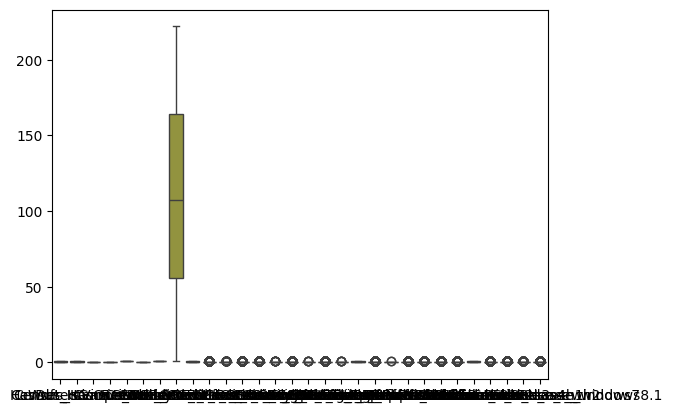

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'data' is your DataFrame
sns.boxplot(data=data)  # Replace 'df' with 'data'
plt.show()

# Example: Remove outliers using Z-score
from scipy.stats import zscore

# Replace 'df' with 'data' in the following lines
data = data[(zscore(data.select_dtypes(include=['float64', 'int64'])) < 3).all(axis=1)]

In [ ]:
# One-hot encoding
data = pd.get_dummies(data, drop_first=True)

In [ ]:
# One-hot encoding
data = pd.get_dummies(data, drop_first=True)
print(data.columns)

Index(['HasDetections', 'Wdft_IsGamer', 'Census_IsVirtualDevice',
       'Census_HasOpticalDiskDrive', 'Firewall', 'SMode', 'IsProtected',
       'CountryIdentifier', 'Census_OSEdition_Core',
       'Census_OSEdition_CoreCountrySpecific', 'Census_OSEdition_CoreN',
       'Census_OSEdition_CoreSingleLanguage', 'Census_OSEdition_Education',
       'Census_OSEdition_EducationN', 'Census_OSEdition_Enterprise',
       'Census_OSEdition_EnterpriseN', 'Census_OSEdition_EnterpriseS',
       'Census_OSEdition_EnterpriseSN', 'Census_OSEdition_Professional',
       'Census_OSEdition_ProfessionalEducation',
       'Census_OSEdition_ProfessionalEducationN',
       'Census_OSEdition_ProfessionalN', 'OsPlatformSubRelease_rs1',
       'OsPlatformSubRelease_rs2', 'OsPlatformSubRelease_rs3',
       'OsPlatformSubRelease_rs4', 'OsPlatformSubRelease_th1',
       'OsPlatformSubRelease_th2', 'OsPlatformSubRelease_windows7',
       'OsPlatformSubRelease_windows8.1'],
      dtype='object')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   HasDetections               100000 non-null  int64  
 1   Wdft_IsGamer                96585 non-null   float64
 2   Census_IsVirtualDevice      99815 non-null   float64
 3   Census_OSEdition            100000 non-null  object 
 4   Census_HasOpticalDiskDrive  100000 non-null  int64  
 5   Firewall                    98924 non-null   float64
 6   SMode                       94068 non-null   float64
 7   IsProtected                 99609 non-null   float64
 8   OsPlatformSubRelease        100000 non-null  object 
 9   CountryIdentifier           100000 non-null  int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 7.6+ MB
HasDetections                    0
Wdft_IsGamer                  3415
Census_IsVirtualDevice         185
Census_OSEdition           

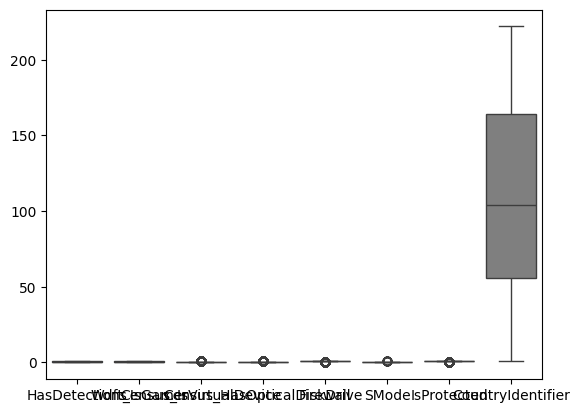

Index(['HasDetections', 'Wdft_IsGamer', 'Census_IsVirtualDevice',
       'Census_HasOpticalDiskDrive', 'Firewall', 'SMode', 'IsProtected',
       'CountryIdentifier', 'Census_OSEdition_Core',
       'Census_OSEdition_CoreCountrySpecific', 'Census_OSEdition_CoreN',
       'Census_OSEdition_CoreSingleLanguage', 'Census_OSEdition_Education',
       'Census_OSEdition_EducationN', 'Census_OSEdition_Enterprise',
       'Census_OSEdition_EnterpriseN', 'Census_OSEdition_EnterpriseS',
       'Census_OSEdition_EnterpriseSN', 'Census_OSEdition_Professional',
       'Census_OSEdition_ProfessionalEducation',
       'Census_OSEdition_ProfessionalEducationN',
       'Census_OSEdition_ProfessionalN',
       'Census_OSEdition_ServerDatacenterEval',
       'Census_OSEdition_ServerSolution', 'Census_OSEdition_ServerStandard',
       'Census_OSEdition_ServerStandardEval', 'OsPlatformSubRelease_rs1',
       'OsPlatformSubRelease_rs2', 'OsPlatformSubRelease_rs3',
       'OsPlatformSubRelease_rs4', 'OsPlatfo

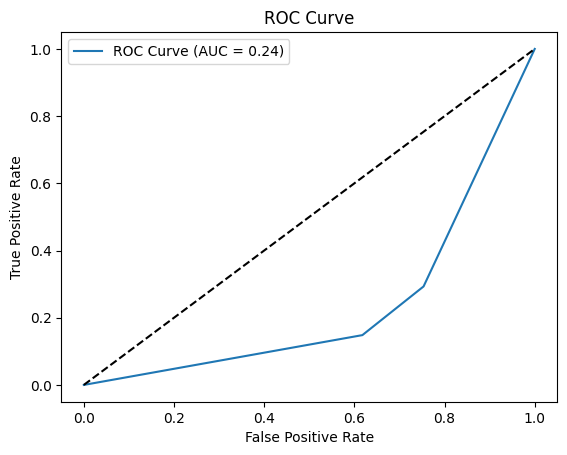

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
# %%
data = pd.read_csv("/content/Microsoft_malware_dataset_min.csv")
# %%
#Data Exploration
data.head()
data.info()
data.describe()
# %%
# Check for missing values
print(data.isnull().sum())

# Handle missing values
# First, identify numerical columns
numerical_cols = data.select_dtypes(include=['number']).columns

# Then, fill missing values in numerical columns with their median
data[numerical_cols] = data[numerical_cols].fillna(data[numerical_cols].median())

# For categorical columns, you can use mode (most frequent value) or a specific value like 'Unknown'
categorical_cols = data.select_dtypes(exclude=['number']).columns
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0]) # Use mode or replace with 'Unknown'

# Drop rows with too many missing values (if applicable)
data.dropna(thresh=len(data.columns) - 5, inplace=True)
# %%
# Remove duplicates
data.drop_duplicates(inplace=True) # Changed 'df' to 'data'
# %%
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'data' is your DataFrame
sns.boxplot(data=data)  # Replace 'df' with 'data'
plt.show()

# Example: Remove outliers using Z-score
from scipy.stats import zscore

# Replace 'df' with 'data' in the following lines
# Instead of removing outliers, cap them at 3 standard deviations
for col in data.select_dtypes(include=['float64', 'int64']).columns:
    data[col] = data[col].clip(lower=data[col].mean() - 3 * data[col].std(),
                              upper=data[col].mean() + 3 * data[col].std())

# %%
# One-hot encoding. Make sure no errors occur here. If the target variable is encoded, drop that column
data = pd.get_dummies(data, drop_first=True)
data = data.drop(columns=['HasDetections_1'], errors='ignore')  # Drop the encoded target if present
# %%
# Print columns to verify one-hot encoding results. This may still have problems if the encoding introduced duplicates
print(data.columns)
# %%
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming 'data' is your preprocessed DataFrame and 'target_column' is the name of your target variable column

# Split data into training and testing sets
X = data.drop(columns=['HasDetections'])  # Replace 'target_column' with your target variable column name
y = data['HasDetections']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check for and handle NaN values in y_test
print(f"Number of NaN values in y_test: {y_test.isnull().sum()}")

# Option 1: Remove rows with NaN values in y_test
# This will reduce the size of your testing set but ensures no NaN values are present
X_test = X_test[y_test.notna()]
y_test = y_test[y_test.notna()]

# Option 2: Impute NaN values in y_test (e.g., with the most frequent value)
# This preserves the size of your testing set but might introduce bias
# from sklearn.impute

# Train the model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict probabilities
y_pred_prob = model.predict_proba(X_test)[:, 1]

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


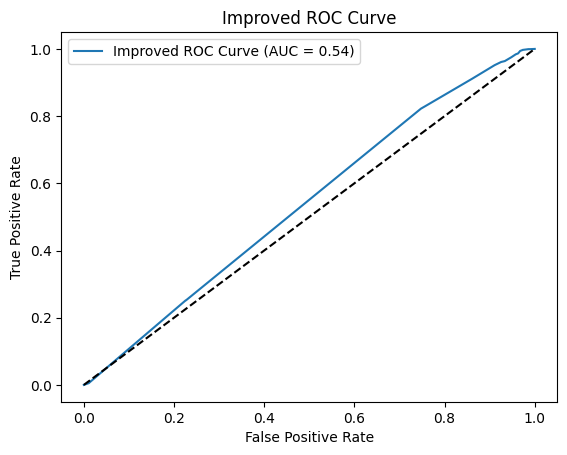

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform grid search
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)

# Best parameters
print(grid_search.best_params_)

# Evaluate the improved model
best_model = grid_search.best_estimator_
y_pred_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'Improved ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Improved ROC Curve')
plt.legend()
plt.show()

##Supervised Learning

In [ ]:
X = data.drop('HasDetections', axis=1)

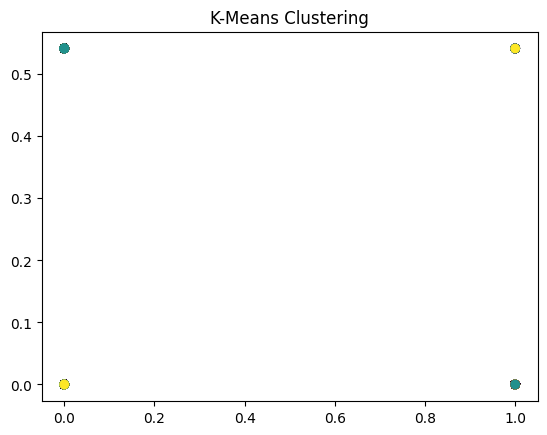

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Apply K-means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

# Plot clusters
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=clusters, cmap='viridis')
plt.title('K-Means Clustering')
plt.show()

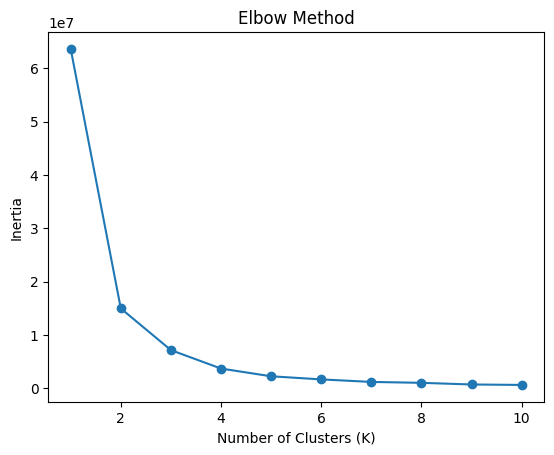

In [ ]:
#Optimal K parameter
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
# Add cluster labels to the dataset
data['Cluster'] = clusters  # Changed 'df' to 'data'

# Analyze cluster characteristics
print(data.groupby('Cluster').mean())  # Changed 'df' to 'data'

         HasDetections  Wdft_IsGamer  Census_IsVirtualDevice  \
Cluster                                                        
0             0.471290      0.355256                0.015778   
1             0.466828      0.341968                0.019982   
2             0.470178      0.335315                0.012653   

         Census_HasOpticalDiskDrive  Firewall     SMode  IsProtected  \
Cluster                                                                
0                          0.215539  0.914198  0.000185     0.809167   
1                          0.219344  0.915398  0.000354     0.818487   
2                          0.212339  0.909690  0.000278     0.806928   

         CountryIdentifier  Census_OSEdition_Core  \
Cluster                                             
0               180.280286               0.349293   
1                38.490123               0.365635   
2               105.879688               0.363599   

         Census_OSEdition_CoreCountrySpecific  ...  